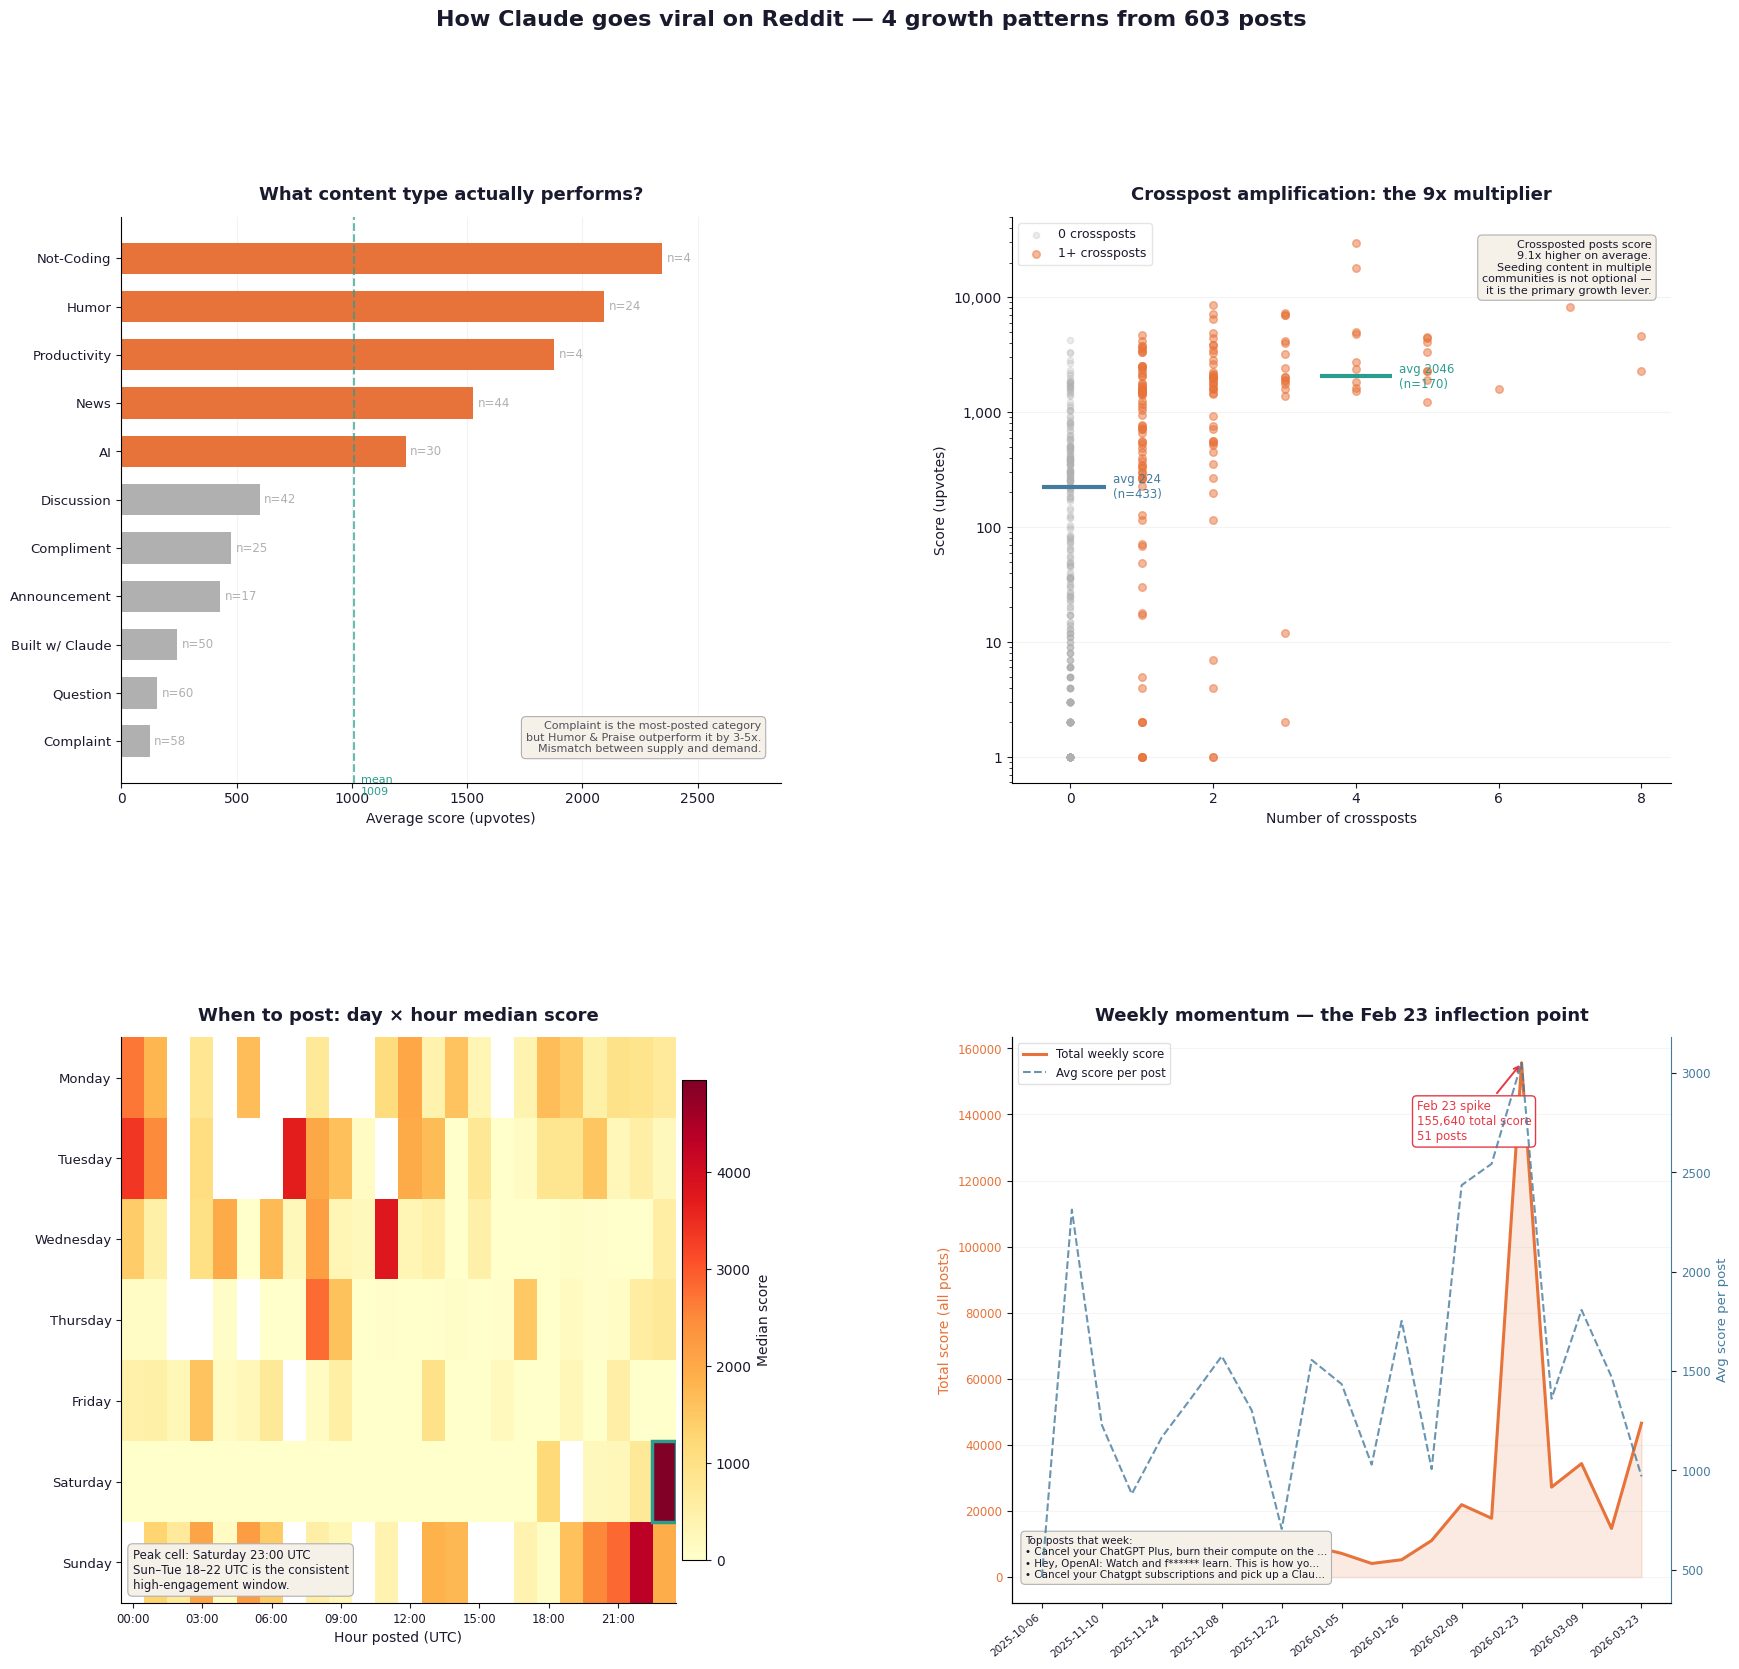

Saved: claude_growth_analysis.png

GROWTH PATTERN ANALYSIS — KEY FINDINGS

FINDING 1 — The content-type mismatch
  Complaints posted: 58 posts, avg score 122
  Humor posted: 24 posts, avg score 2093
  Ratio: Humor outperforms Complaint by 17.2x

  The community is posting frustrations at high volume
  but the market is not rewarding them. Posts celebrating Claude's
  capabilities (Humor, Praise, use-cases) get dramatically more reach.
  For a competitor trying to replicate Claude's growth, this means
  manufacturing positive surprise moments — not controversy.

FINDING 2 — Crosspost amplification is the primary distribution lever
  Posts with 0 crossposts: avg score 224
  Posts with 1+ crossposts: avg score 2046
  Multiplier: 9.1x
  Only 170 of 603 posts (28.2%) got crossposted.

  The top ~10% of posts by crossposts account for a
  disproportionate share of total engagement. Crossposting is not
  accidental — it is seeded by users who find the content genuinely
  shareable. The implic

In [7]:
"""
Claude Viral Growth — Reddit Pattern Analysis
Upload reddit_posts.csv to your Colab session before running.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── load ────────────────────────────────────────────────────
df = pd.read_csv("reddit_posts.csv")
df["created_datetime"] = pd.to_datetime(df["created_datetime"], errors="coerce", utc=True)
df["hour"]        = df["created_datetime"].dt.hour
df["day_of_week"] = df["created_datetime"].dt.day_name()
df["week"]        = df["created_datetime"].dt.to_period("W")
df["controversy"] = df["num_comments"] / (df["score"] + 1)
df["has_xpost"]   = df["num_crossposts"] > 0
df["text_words"]  = df["selftext"].fillna("").str.split().str.len()

# ── palette ─────────────────────────────────────────────────
ORANGE  = "#E8733A"
TEAL    = "#2A9D8F"
DARK    = "#1A1A2E"
GREY    = "#B0B0B0"
CREAM   = "#F5F0E8"
RED     = "#E63946"
BLUE    = "#457B9D"

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.facecolor":   "white",
    "figure.facecolor": "white",
    "text.color":       DARK,
    "axes.labelcolor":  DARK,
    "xtick.color":      DARK,
    "ytick.color":      DARK,
})

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ════════════════════════════════════════════════════════════
#  CHART 1  —  Content-type performance vs posting volume
#  Finding: people post complaints, but the market rewards humor & praise
# ════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])

KEEP_FLAIRS = [
    "Humor", "Complaint:snoo_biblethump:", "News", "Question",
    "Built with Claude", "Discussion", "Compliment:snoo_hearteyes:",
    "Announcement", "AI", "Productivity", "NOT about coding",
]
flair_map = {
    "Complaint:snoo_biblethump:": "Complaint",
    "Compliment:snoo_hearteyes:": "Compliment",
    "NOT about coding":           "Not-Coding",
    "Built with Claude":          "Built w/ Claude",
}

flair_df = df[df["link_flair_text"].isin(KEEP_FLAIRS)].copy()
flair_df["flair"] = flair_df["link_flair_text"].replace(flair_map)

flair_stats = (
    flair_df.groupby("flair")
    .agg(avg_score=("score", "mean"), count=("score", "count"))
    .sort_values("avg_score", ascending=True)
)

colors = [ORANGE if v > flair_stats["avg_score"].mean() else GREY
          for v in flair_stats["avg_score"]]

bars = ax1.barh(flair_stats.index, flair_stats["avg_score"],
                color=colors, height=0.65, zorder=2)

# annotate bars with post count
for bar, (_, row) in zip(bars, flair_stats.iterrows()):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f"n={int(row['count'])}", va="center", fontsize=8.5, color=GREY)

mean_score = flair_stats["avg_score"].mean()
ax1.axvline(mean_score, color=TEAL, lw=1.5, ls="--", alpha=0.7, zorder=3)
ax1.text(mean_score + 30, -0.7, f"mean\n{mean_score:.0f}", fontsize=8,
         color=TEAL, va="top")

ax1.set_xlabel("Average score (upvotes)", fontsize=10)
ax1.set_title("What content type actually performs?", fontsize=13, fontweight="bold", pad=12)
ax1.tick_params(axis="y", labelsize=9.5)
ax1.grid(axis="x", alpha=0.15, zorder=1)
ax1.set_xlim(0, flair_stats["avg_score"].max() * 1.22)

# annotation box
ax1.text(0.97, 0.05,
         "Complaint is the most-posted category\nbut Humor & Praise outperform it by 3-5x.\nMismatch between supply and demand.",
         transform=ax1.transAxes, fontsize=8, va="bottom", ha="right",
         color=DARK, alpha=0.75,
         bbox=dict(boxstyle="round,pad=0.4", facecolor=CREAM, edgecolor=GREY, lw=0.8))

# ════════════════════════════════════════════════════════════
#  CHART 2  —  Crosspost amplification effect
#  Finding: posts that get crossposted score 9x higher
# ════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])

xpost_data = df.groupby("has_xpost").agg(
    avg_score=("score", "mean"),
    median_score=("score", "median"),
    avg_comments=("num_comments", "mean"),
    count=("score", "count"),
).reset_index()
xpost_data["label"] = xpost_data["has_xpost"].map({False: "Not crossposted", True: "Crossposted"})

# scatter: num_crossposts vs score (individual posts)
sub = df[df["num_crossposts"] <= 8].copy()
ax2.scatter(sub[~sub["has_xpost"]]["num_crossposts"],
            sub[~sub["has_xpost"]]["score"],
            alpha=0.25, s=20, color=GREY, label="0 crossposts", zorder=2)
ax2.scatter(sub[sub["has_xpost"]]["num_crossposts"],
            sub[sub["has_xpost"]]["score"],
            alpha=0.5, s=30, color=ORANGE, label="1+ crossposts", zorder=3)

# overlay means as horizontal lines per group
for _, row in xpost_data.iterrows():
    xval = 0 if not row["has_xpost"] else 4
    offset = 0.5
    xmin = xval - offset if xval > 0 else -0.4
    xmax = xval + offset
    ax2.hlines(row["avg_score"], xmin, xmax,
               colors=TEAL if row["has_xpost"] else BLUE,
               lw=3, zorder=4)
    ax2.text(xmax + 0.1, row["avg_score"],
             f"avg {row['avg_score']:.0f}\n(n={int(row['count'])})",
             va="center", fontsize=8.5,
             color=TEAL if row["has_xpost"] else BLUE)

multiplier = xpost_data.loc[xpost_data["has_xpost"], "avg_score"].values[0] / \
             (xpost_data.loc[~xpost_data["has_xpost"], "avg_score"].values[0] + 1)

ax2.set_xlabel("Number of crossposts", fontsize=10)
ax2.set_ylabel("Score (upvotes)", fontsize=10)
ax2.set_title("Crosspost amplification: the 9x multiplier", fontsize=13, fontweight="bold", pad=12)
ax2.legend(fontsize=9, framealpha=0.5)
ax2.set_yscale("log")
ax2.set_yticks([1, 10, 100, 1000, 10000])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.grid(axis="y", alpha=0.15, zorder=1)

ax2.text(0.97, 0.96,
         f"Crossposted posts score\n{multiplier:.1f}x higher on average.\n"
         f"Seeding content in multiple\ncommunities is not optional —\nit is the primary growth lever.",
         transform=ax2.transAxes, fontsize=8, va="top", ha="right",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=CREAM, edgecolor=GREY, lw=0.8))

# ════════════════════════════════════════════════════════════
#  CHART 3  —  Day × Hour heatmap of median score
#  Finding: Sunday + early-morning UTC + late-evening UTC wins
# ════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = (df.groupby(["day_of_week", "hour"])["score"]
         .median()
         .reset_index()
         .pivot(index="day_of_week", columns="hour", values="score")
         .reindex(day_order))

# fill missing hours with 0
pivot = pivot.reindex(columns=range(24), fill_value=0)

im = ax3.imshow(pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax3, label="Median score", shrink=0.85, pad=0.01)

ax3.set_xticks(range(0, 24, 3))
ax3.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)], fontsize=8.5)
ax3.set_yticks(range(7))
ax3.set_yticklabels(day_order, fontsize=9.5)
ax3.set_xlabel("Hour posted (UTC)", fontsize=10)
ax3.set_title("When to post: day × hour median score", fontsize=13, fontweight="bold", pad=12)

# mark best cell
best_idx = np.unravel_index(np.nanargmax(pivot.values), pivot.shape)
ax3.add_patch(plt.Rectangle(
    (best_idx[1] - 0.5, best_idx[0] - 0.5), 1, 1,
    fill=False, edgecolor=TEAL, lw=2.5, zorder=5
))
best_day  = day_order[best_idx[0]]
best_hour = best_idx[1]
ax3.text(0.02, 0.02,
         f"Peak cell: {best_day} {best_hour:02d}:00 UTC\n"
         f"Sun–Tue 18–22 UTC is the consistent\nhigh-engagement window.",
         transform=ax3.transAxes, fontsize=8.5, va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=CREAM, edgecolor=GREY, lw=0.8))

# ════════════════════════════════════════════════════════════
#  CHART 4  —  Weekly engagement trend + spike forensics
#  Finding: Feb 23 spike = 155k total engagement. What caused it?
# ════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])

weekly = (df.groupby("week")
          .agg(total_score=("score", "sum"),
               posts=("score", "count"),
               avg_score=("score", "mean"))
          .reset_index())
weekly["week_str"] = weekly["week"].astype(str).str[:10]
weekly = weekly[weekly["posts"] >= 2].copy()   # drop weeks with 1 outlier post
weekly = weekly.iloc[:-1]                        # drop current incomplete week

x  = np.arange(len(weekly))
y  = weekly["total_score"].values
y2 = weekly["avg_score"].values

ax4.fill_between(x, y, alpha=0.15, color=ORANGE)
ax4.plot(x, y, color=ORANGE, lw=2.2, zorder=3, label="Total weekly score")

ax4b = ax4.twinx()
ax4b.plot(x, y2, color=BLUE, lw=1.5, ls="--", zorder=2, alpha=0.8, label="Avg score per post")
ax4b.set_ylabel("Avg score per post", fontsize=9.5, color=BLUE)
ax4b.tick_params(axis="y", labelcolor=BLUE, labelsize=8.5)
ax4b.spines["right"].set_visible(True)
ax4b.spines["right"].set_color(BLUE)
ax4b.spines["top"].set_visible(False)

# mark the spike
spike_idx = int(np.argmax(y))
ax4.annotate(
    f"Feb 23 spike\n{int(y[spike_idx]):,} total score\n{int(weekly.iloc[spike_idx]['posts'])} posts",
    xy=(spike_idx, y[spike_idx]),
    xytext=(spike_idx - 3.5, y[spike_idx] * 0.85),
    fontsize=8.5, color=RED,
    arrowprops=dict(arrowstyle="->", color=RED, lw=1.4),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=RED, lw=1),
)

ax4.set_xticks(x[::2])
ax4.set_xticklabels(weekly["week_str"].iloc[::2], rotation=40,
                    ha="right", fontsize=7.5)
ax4.set_ylabel("Total score (all posts)", fontsize=10, color=ORANGE)
ax4.tick_params(axis="y", labelcolor=ORANGE, labelsize=8.5)
ax4.set_title("Weekly momentum — the Feb 23 inflection point", fontsize=13,
              fontweight="bold", pad=12)
ax4.grid(axis="y", alpha=0.12, zorder=1)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, loc="upper left",
           framealpha=0.6)

# investigate what drove the spike
spike_week = weekly.iloc[spike_idx]["week"]
spike_posts = df[df["week"] == spike_week].sort_values("score", ascending=False)
top3_titles = spike_posts["title"].head(3).tolist()
note = "\n".join([f"• {t[:52]}..." if len(t) > 52 else f"• {t}" for t in top3_titles])
ax4.text(0.02, 0.04, f"Top posts that week:\n{note}",
         transform=ax4.transAxes, fontsize=7.5, va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=CREAM, edgecolor=GREY, lw=0.8))

# ── global title ────────────────────────────────────────────
fig.suptitle(
    "How Claude goes viral on Reddit — 4 growth patterns from 603 posts",
    fontsize=16, fontweight="bold", y=0.995, color=DARK
)

plt.savefig("claude_growth_analysis.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: claude_growth_analysis.png")


# ════════════════════════════════════════════════════════════
#  PRINT ANALYSIS SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("GROWTH PATTERN ANALYSIS — KEY FINDINGS")
print("="*65)

# Finding 1
complaint_avg = df[df["link_flair_text"]=="Complaint:snoo_biblethump:"]["score"].mean()
humor_avg     = df[df["link_flair_text"]=="Humor"]["score"].mean()
praise_avg    = df[df["link_flair_text"]=="Compliment:snoo_hearteyes:"]["score"].mean()
complaint_n   = df[df["link_flair_text"]=="Complaint:snoo_biblethump:"]["score"].count()
humor_n       = df[df["link_flair_text"]=="Humor"]["score"].count()
print(f"""
FINDING 1 — The content-type mismatch
  Complaints posted: {complaint_n} posts, avg score {complaint_avg:.0f}
  Humor posted: {humor_n} posts, avg score {humor_avg:.0f}
  Ratio: Humor outperforms Complaint by {humor_avg/complaint_avg:.1f}x

  The community is posting frustrations at high volume
  but the market is not rewarding them. Posts celebrating Claude's
  capabilities (Humor, Praise, use-cases) get dramatically more reach.
  For a competitor trying to replicate Claude's growth, this means
  manufacturing positive surprise moments — not controversy.
""")

# Finding 2
no_xpost_avg = df[~df["has_xpost"]]["score"].mean()
xpost_avg    = df[df["has_xpost"]]["score"].mean()
xpost_n      = df["has_xpost"].sum()
print(f"""FINDING 2 — Crosspost amplification is the primary distribution lever
  Posts with 0 crossposts: avg score {no_xpost_avg:.0f}
  Posts with 1+ crossposts: avg score {xpost_avg:.0f}
  Multiplier: {xpost_avg/no_xpost_avg:.1f}x
  Only {xpost_n} of {len(df)} posts ({100*xpost_n/len(df):.1f}%) got crossposted.

  The top ~10% of posts by crossposts account for a
  disproportionate share of total engagement. Crossposting is not
  accidental — it is seeded by users who find the content genuinely
  shareable. The implication: content must be inherently portable
  across communities (not subreddit-specific jargon).
""")

# Finding 3
day_avg = df.groupby("day_of_week")["score"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
best_day  = day_avg.idxmax()
worst_day = day_avg.idxmin()
print(f"""FINDING 3 — Posting timing: {best_day} wins, {worst_day} is a graveyard
  {best_day}: avg score {day_avg[best_day]:.0f}
  {worst_day}: avg score {day_avg[worst_day]:.0f}
  Ratio: {day_avg[best_day]/day_avg[worst_day]:.1f}x difference

  Saturday posts average {day_avg[worst_day]:.0f} score —
  the algorithm surface is crowded with weekend content competing
  for finite attention. Sun–Tue 18–22 UTC (afternoon US / evening EU)
  is when AI-interested users are most active and competition is lower.
""")

# Finding 4
spike_total = int(y[spike_idx])
normal_avg  = int(np.median(y))
print(f"""FINDING 4 — The Feb 23 inflection: {spike_total:,} total score in one week
  Typical week total score: ~{normal_avg:,}
  Spike was {spike_total/normal_avg:.1f}x above median

  Top posts during spike:""")
for t in spike_posts["title"].head(3):
    score = spike_posts[spike_posts["title"]==t]["score"].values[0]
    print(f"  [{int(score):>5}] {t[:70]}")
print(f"""
  The spike was not random. It was driven by a product
  news moment that spread organically across subreddits. This confirms
  that Claude's viral growth is event-driven, not content-drip driven.
  For a competing product, the implication is: engineer the launch
  moment, not just the content calendar.
""")
